In [1]:
import tensorflow as tf
from tensorflow.keras import datasets,layers, models
import matplotlib.pyplot as plt 
import numpy as np

In [2]:
(X_train,y_train),(X_test,y_test)=datasets.cifar10.load_data()

In [3]:
print(X_test.shape,X_train.shape)

(10000, 32, 32, 3) (50000, 32, 32, 3)


In [4]:
classes=['aeroplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

In [5]:
y_train = y_train.reshape(-1,)
y_train[:5]

array([6, 9, 9, 4, 1], dtype=uint8)

In [6]:
def plot_sample(X,y,index):
    plt.figure(figsize=(1,2))
    plt.imshow(X_train[index])
    plt.xlabel(classes[y[index]])

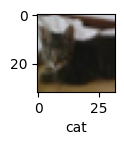

In [7]:
plot_sample(X_train,y_train,9)

In [8]:
X_train = X_train/255
X_test = X_test/255

In [9]:
model = models.Sequential([
        layers.Flatten(input_shape=(32,32,3)),
        layers.Dense(3000, activation='relu'),
        layers.Dense(1000, activation='relu'),
        layers.Dense(10, activation='softmax')    
    ])

model.compile(optimizer='SGD',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(X_train, y_train, epochs=5)

C:\Users\HARENDRA SINGH\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 110s 69ms/step - accuracy: 0.3093 - loss: 1.9316
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 109s 69ms/step - accuracy: 0.4216 - loss: 1.6409
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 107s 68ms/step - accuracy: 0.4539 - loss: 1.5477
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 109s 69ms/step - accuracy: 0.4723 - loss: 1.4909
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 109s 69ms/step - accuracy: 0.4958 - loss: 1.4377


In [10]:
model.evaluate(X_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.4733 - loss: 1.5087


[1.5134387016296387, 0.46779999136924744]

In [11]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
y_pred = model.predict(X_test)
y_pred_classes = [np.argmax(element) for element in y_pred]
print('Classification report \n',classification_report(y_test,y_pred_classes))

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step
Classification report 
               precision    recall  f1-score   support

           0       0.67      0.39      0.49      1000
           1       0.77      0.39      0.51      1000
           2       0.32      0.41      0.36      1000
           3       0.32      0.34      0.33      1000
           4       0.45      0.31      0.36      1000
           5       0.43      0.30      0.36      1000
           6       0.40      0.74      0.52      1000
           7       0.46      0.61      0.53      1000
           8       0.62      0.62      0.62      1000
           9       0.57      0.58      0.57      1000

    accuracy                           0.47     10000
   macro avg       0.50      0.47      0.46     10000
weighted avg       0.50      0.47      0.46     10000



In [12]:

cnn = models.Sequential([
    layers.Conv2D(filters=32, kernel_size=(3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(filters=64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])



C:\Users\HARENDRA SINGH\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
cnn.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [14]:
cnn.fit(X_train,y_train,epochs=10)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 50s 29ms/step - accuracy: 0.3878 - loss: 1.6829
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 44s 28ms/step - accuracy: 0.6026 - loss: 1.1284
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 43s 27ms/step - accuracy: 0.6577 - loss: 0.9807
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 43s 27ms/step - accuracy: 0.6903 - loss: 0.8902
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 46s 29ms/step - accuracy: 0.7125 - loss: 0.8282
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 94s 37ms/step - accuracy: 0.7401 - loss: 0.7555
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 43s 27ms/step - accuracy: 0.7560 - loss: 0.7027
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 27ms/step - accuracy: 0.7723 - loss: 0.6554
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 26ms/step - accuracy: 0.7854 - loss: 0.6175
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 43s 27ms/step - accuracy: 0.7959 - loss: 0.5871


In [15]:
cnn.evaluate(X_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.6968 - loss: 0.9415


[0.9610216021537781, 0.6901999711990356]

In [16]:
y_test

array([[3],
       [8],
       [8],
       ...,
       [5],
       [1],
       [7]], dtype=uint8)

In [17]:
y_test = y_test.reshape(-1,)
y_test[:5]

array([3, 8, 8, 0, 6], dtype=uint8)

In [18]:
y_pred = cnn.predict(X_test)
y_pred[:5]

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step


array([[1.0870262e-03, 3.4184370e-05, 1.1677476e-02, 8.0216265e-01,
        3.7319609e-03, 2.5263373e-02, 1.5260884e-01, 5.8012006e-06,
        3.4275395e-03, 1.0689183e-06],
       [2.3206843e-03, 3.2983933e-02, 3.8600292e-06, 3.9754714e-06,
        4.9263150e-08, 3.5681177e-07, 1.6218119e-07, 1.1131222e-07,
        9.6383947e-01, 8.4740610e-04],
       [4.0891975e-02, 1.0387161e-02, 3.4239900e-04, 1.7580215e-03,
        2.0139251e-04, 2.5831506e-04, 1.2375443e-04, 1.8972931e-03,
        9.4335085e-01, 7.8886270e-04],
       [9.2782730e-01, 3.3456120e-03, 2.0699010e-03, 1.5232611e-03,
        1.7147486e-03, 8.9803780e-06, 9.1358938e-04, 2.1365604e-05,
        6.2321857e-02, 2.5341337e-04],
       [4.3765458e-06, 3.2028131e-06, 1.8529147e-02, 4.4512939e-02,
        4.7260311e-02, 3.2963108e-03, 8.8616097e-01, 1.0477296e-06,
        2.3134607e-04, 3.7776005e-07]], dtype=float32)

In [19]:
y_classes = [np.argmax(i) for i in y_pred]
y_classes[:5]

[3, 8, 8, 0, 6]

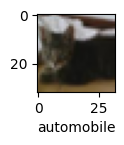

In [20]:
plot_sample(X_test,y_test,9)

In [21]:
classes[y_classes[9]]

'automobile'

In [22]:
print('classification_report: \n',classification_report(y_test,y_classes))

classification_report: 
               precision    recall  f1-score   support

           0       0.72      0.75      0.73      1000
           1       0.79      0.84      0.82      1000
           2       0.62      0.56      0.59      1000
           3       0.54      0.48      0.51      1000
           4       0.64      0.65      0.64      1000
           5       0.69      0.47      0.55      1000
           6       0.59      0.90      0.71      1000
           7       0.77      0.71      0.74      1000
           8       0.77      0.81      0.79      1000
           9       0.83      0.74      0.78      1000

    accuracy                           0.69     10000
   macro avg       0.69      0.69      0.69     10000
weighted avg       0.69      0.69      0.69     10000

